In [6]:
# Базовые библиотеки
import os
import sys
import math
import time
import random
from typing import Tuple, Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from dataclasses import dataclass
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.datasets import VOCDetection
import json
from pathlib import Path

from PIL import Image
import torch.utils.data
import xml.etree.ElementTree as ET  

In [3]:
# фиксация seed
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [43]:
# определение устройства
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print('Python: ',sys.version)

Device: cpu
torch: 2.10.0+cpu
Python:  3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


ЧАСТЬ А

датасет CIFAR100

In [124]:
# для эксперементов C1 и C2

CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

IMG_SIZE = 224
data_dir = "./data"

tf_train_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])
train_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),     # случайный кроп 32x32 с отступом
    transforms.RandomHorizontalFlip(p=0.5),   # случайный переворот
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])
tf_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

ds_train_no_aug = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=tf_train_no_aug)
ds_train_aug = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_aug)
ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=tf_test)

# для эксперементов C3 и C4

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_aug_ResNet18 = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tf_test_ResNet18 = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ds_train_aug_ResNet18 = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_aug_ResNet18)
ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=tf_test_ResNet18)
ds_test_ResNet18 = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=tf_test_ResNet18)

In [81]:
class_names = ds_train_aug.classes # тут неважно какой ds указывать
print("classes:", class_names)
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'will

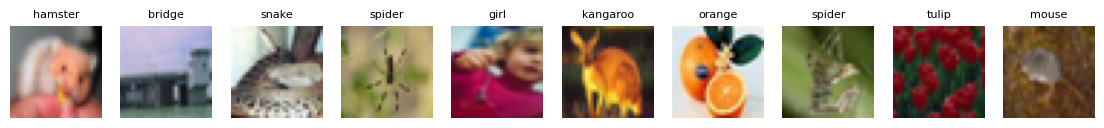

In [48]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()
train_loader, val_loader, test_loader = make_loaders(ds_train_no_aug, ds_test,128)
show_images(train_loader, n=10)

In [123]:
# Для эксперементов С1 и С2
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size,
    val_ratio: float = 0.2,
    seed: int = 42,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader
# Для эксперементов С3 и С4
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = 64,
    val_ratio: float = 0.2,
    seed: int = 42,
    fast_mode: bool = True,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

In [118]:
# обучение и логирование для эксперементов C1 и C2
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()
# обучение и логирование для эксперементов C3 и C4
def train_one_epoch_ResNet18(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate_ResNet18(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr_ResNet18(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit_ResNet18(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_ResNet18(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate_ResNet18(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr_ResNet18(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr_ResNet18(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history_ResNet18(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

In [150]:
def save_plot_history_ResNet18(path,hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.savefig(path, dpi=100,bbox_inches='tight')
    plt.close()

In [119]:
# архитектура модели для эксперемента C1,C2
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
# архитектура модели для эксперемента C3,C4
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

weights: ResNet18_Weights.IMAGENET1K_V1


Архитектрура модели для эксперемента C1 и C2

In [71]:
cnn = SimpleCNN(100).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Trainable params: 643492


Экспермент C1 (simple-cnn-base): простая CNN без аугментаций.

In [58]:
train_loader_с1, val_loader_с1, test_loader_с1 = make_loaders(ds_train_no_aug, ds_test,128)

batch_с1 = next(iter(train_loader_с1))
x_с1, y_с1 = batch_с1
print("x:", x_с1.shape, x_с1.dtype)
print("y:", y_с1.shape, y_с1.dtype)

x: torch.Size([128, 3, 32, 32]) torch.float32
y: torch.Size([128]) torch.int64


Epoch 01/15 | train loss 3.7561, acc 0.130 | val loss 3.2323, acc 0.216 | 58.7s
Epoch 02/15 | train loss 2.9299, acc 0.271 | val loss 2.7665, acc 0.309 | 57.4s
Epoch 03/15 | train loss 2.5326, acc 0.352 | val loss 2.5744, acc 0.345 | 59.0s
Epoch 04/15 | train loss 2.2364, acc 0.416 | val loss 2.4233, acc 0.380 | 58.9s
Epoch 05/15 | train loss 1.9968, acc 0.471 | val loss 2.4183, acc 0.385 | 56.6s
Epoch 06/15 | train loss 1.7850, acc 0.516 | val loss 2.3985, acc 0.394 | 58.3s
Epoch 07/15 | train loss 1.5809, acc 0.564 | val loss 2.4383, acc 0.401 | 60.2s
Epoch 08/15 | train loss 1.3983, acc 0.608 | val loss 2.5558, acc 0.394 | 60.7s
Epoch 09/15 | train loss 1.2222, acc 0.651 | val loss 2.6202, acc 0.397 | 60.9s
Epoch 10/15 | train loss 1.0469, acc 0.698 | val loss 2.7881, acc 0.398 | 60.9s
Epoch 11/15 | train loss 0.8938, acc 0.739 | val loss 2.9551, acc 0.395 | 59.9s
Epoch 12/15 | train loss 0.7575, acc 0.774 | val loss 3.2515, acc 0.382 | 61.2s
Epoch 13/15 | train loss 0.6181, acc 0.8

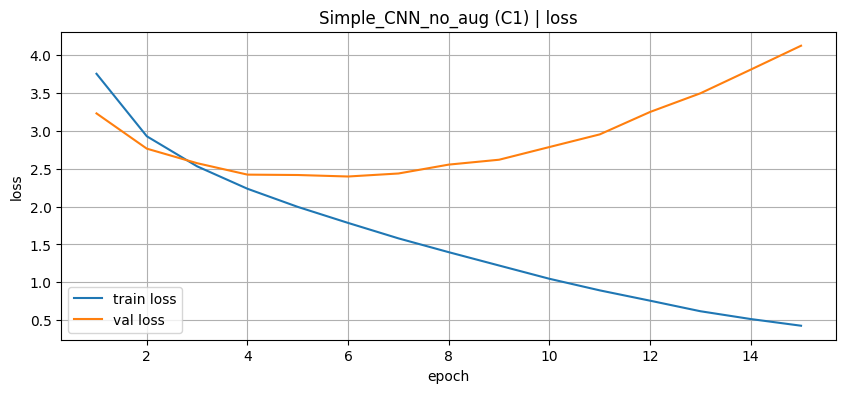

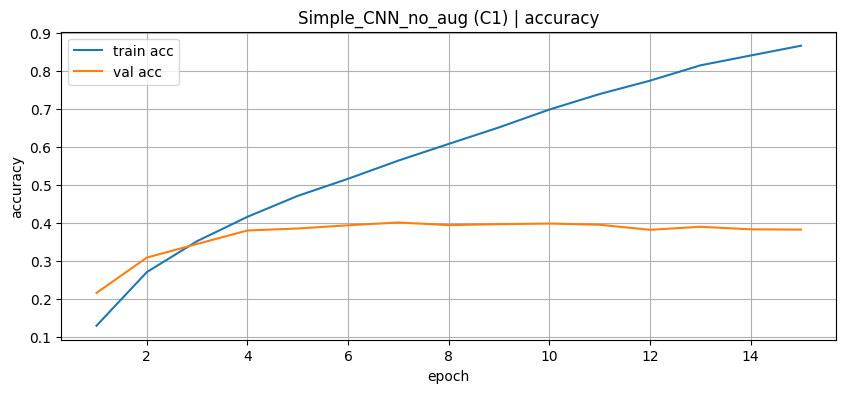

best_val_acc:  0.4012


In [64]:
model_c1 = SimpleCNN().to(DEVICE)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3, weight_decay=0.0)
criterion_c1 = nn.CrossEntropyLoss()
hist_c1 = fit(model_c1, train_loader_с1, val_loader_с1, optimizer_c1, criterion_c1, epochs=15, verbose=True)
plot_history(hist_c1, title="Simple_CNN_no_aug (C1)")
best_val_acc_с1 = float(np.nanmax(hist_c1["val_acc"])) if len(hist_c1["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc_с1)

C2 (simple-cnn-aug): та же CNN, но с разумными аугментациями.

In [82]:
train_loader_с2, val_loader_с2, test_loader_с2 = make_loaders(ds_train_aug, ds_test,128)

batch_с2 = next(iter(train_loader_с2))
x_с2, y_с2 = batch_с2
print("x:", x_с2.shape, x_с2.dtype)
print("y:", y_с2.shape, y_с2.dtype)

x: torch.Size([128, 3, 32, 32]) torch.float32
y: torch.Size([128]) torch.int64


Epoch 01/15 | train loss 3.9268, acc 0.096 | val loss 3.5734, acc 0.155 | 59.7s
Epoch 02/15 | train loss 3.3255, acc 0.193 | val loss 3.1725, acc 0.225 | 59.6s
Epoch 03/15 | train loss 3.0135, acc 0.249 | val loss 2.9418, acc 0.267 | 62.6s
Epoch 04/15 | train loss 2.8162, acc 0.291 | val loss 2.8312, acc 0.291 | 56.3s
Epoch 05/15 | train loss 2.6504, acc 0.322 | val loss 2.6889, acc 0.326 | 55.5s
Epoch 06/15 | train loss 2.5248, acc 0.349 | val loss 2.6603, acc 0.333 | 57.7s
Epoch 07/15 | train loss 2.4177, acc 0.371 | val loss 2.4933, acc 0.364 | 61.9s
Epoch 08/15 | train loss 2.3254, acc 0.391 | val loss 2.4984, acc 0.362 | 61.0s
Epoch 09/15 | train loss 2.2532, acc 0.408 | val loss 2.4262, acc 0.378 | 59.3s
Epoch 10/15 | train loss 2.1703, acc 0.425 | val loss 2.3658, acc 0.390 | 60.1s
Epoch 11/15 | train loss 2.1156, acc 0.438 | val loss 2.3799, acc 0.389 | 77.0s
Epoch 12/15 | train loss 2.0647, acc 0.449 | val loss 2.3094, acc 0.402 | 91.3s
Epoch 13/15 | train loss 2.0107, acc 0.4

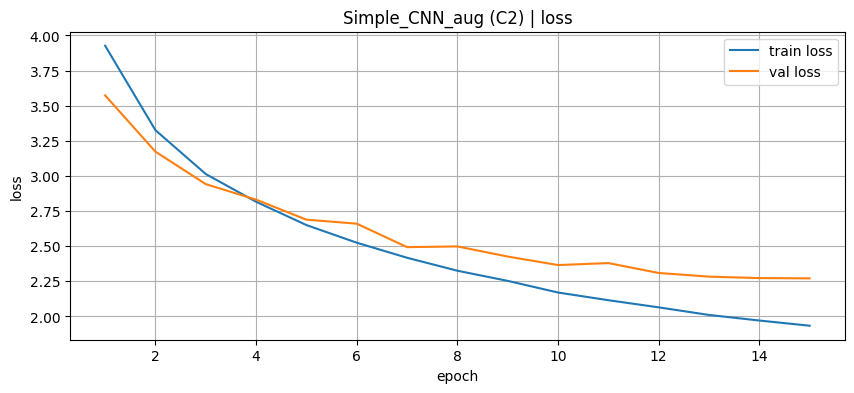

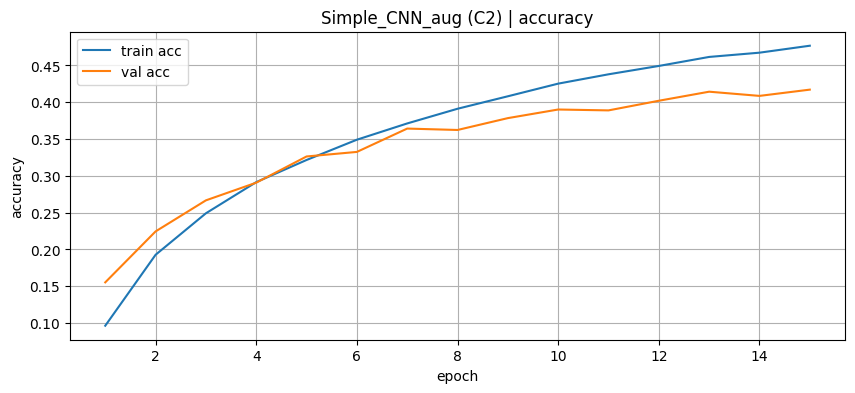

best_val_acc:  0.4171


In [87]:
model_c2 = SimpleCNN().to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3, weight_decay=0.0)
criterion_c2 = nn.CrossEntropyLoss()
hist_c2 = fit(model_c2, train_loader_с2, val_loader_с2, optimizer_c2, criterion_c2, epochs=15, verbose=True)
plot_history(hist_c2, title="Simple_CNN_aug (C2)")
best_val_acc_с2 = float(np.nanmax(hist_c2["val_acc"])) if len(hist_c2["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc_с2)

Архитектрура модели для эксперемента C3 и C4

In [122]:
model = build_resnet18(num_classes=100, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

C3 (resnet18-head-only): ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова.

In [125]:
train_loader_с3, val_loader_с3, test_loader_с3 = make_loaders_tl(ds_train_aug_ResNet18,ds_train_eval, ds_test_ResNet18)

batch_с3 = next(iter(train_loader_с3))
x_с3, y_с3 = batch_с3
print("x:", x_с3.shape, x_с3.dtype)
print("y:", y_с3.shape, y_с3.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Trainable params (head-only): 51300

Phase 1: head-only training
Epoch 01/10 | lr 1.00e-03 | train loss 4.3001, acc 0.084 | val loss 3.7229, acc 0.203 | 173.5s
Epoch 02/10 | lr 1.00e-03 | train loss 3.2915, acc 0.288 | val loss 3.0494, acc 0.323 | 164.6s
Epoch 03/10 | lr 1.00e-03 | train loss 2.7291, acc 0.408 | val loss 2.7874, acc 0.330 | 165.0s
Epoch 04/10 | lr 1.00e-03 | train loss 2.3927, acc 0.456 | val loss 2.5610, acc 0.385 | 163.3s
Epoch 05/10 | lr 1.00e-03 | train loss 2.1463, acc 0.504 | val loss 2.4369, acc 0.403 | 161.7s
Epoch 06/10 | lr 1.00e-03 | train loss 1.9886, acc 0.529 | val loss 2.3456, acc 0.409 | 164.5s
Epoch 07/10 | lr 1.00e-03 | train loss 1.8458, acc 0.550 | val loss 2.2422, acc 0.430 | 167.6s
Epoch 08/10 | lr 1.00e-03 | train loss 1.7470, acc 0.572 | val loss 2.2053, acc 0.431 | 223.8s
Epoch 09/10 | lr 1.00e-03 | train loss 1.6576, acc 0.594 | val loss 2.1966, acc 0.432 | 239.3s
Epoch 10/10 | lr 1.00e-03 | train loss 1.5945, acc 0.609 | val loss 2.1400, acc 

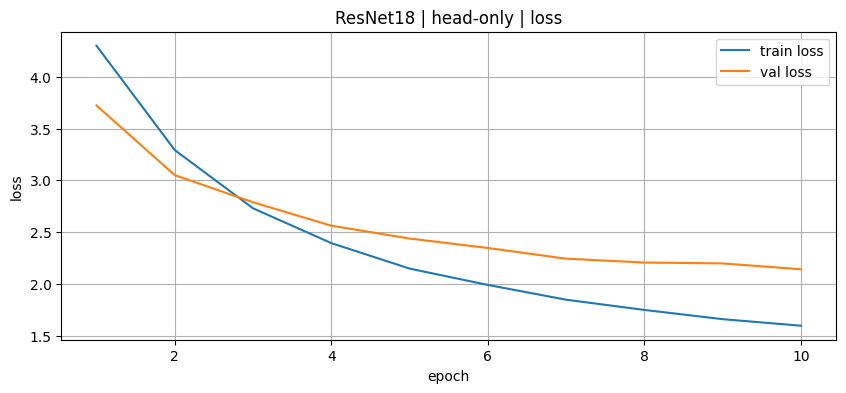

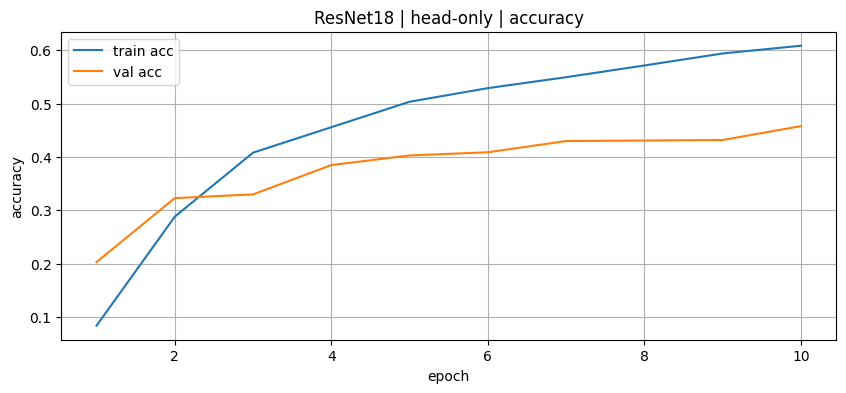

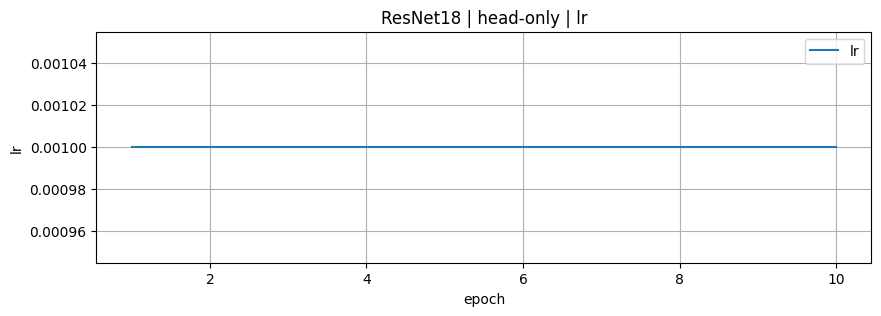

best_val_acc:  0.458


In [126]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=100, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit_ResNet18(model_head, train_loader_с3, val_loader_с3, optimizer_head, criterion, epochs=10, verbose=True)
plot_history_ResNet18(hist_head, title="ResNet18 | head-only")
best_val_acc_с3 = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc_с3)

C4 (resnet18-finetune): ResNet18 с pretrained weights; частичное fine-tune 

Trainable params (layer4+fc): 8445028

Phase 2: fine-tuning layer4 + fc
Epoch 01/10 | lr 1.00e-04 | train loss 1.4506, acc 0.610 | val loss 1.8787, acc 0.495 | 303.7s
Epoch 02/10 | lr 1.00e-04 | train loss 0.9753, acc 0.731 | val loss 1.7920, acc 0.510 | 306.7s
Epoch 03/10 | lr 1.00e-04 | train loss 0.7133, acc 0.814 | val loss 1.7187, acc 0.541 | 306.1s
Epoch 04/10 | lr 1.00e-04 | train loss 0.5571, acc 0.861 | val loss 1.6954, acc 0.545 | 316.8s
Epoch 05/10 | lr 1.00e-04 | train loss 0.4438, acc 0.893 | val loss 1.7081, acc 0.561 | 239.4s
Epoch 06/10 | lr 1.00e-04 | train loss 0.3230, acc 0.932 | val loss 1.6969, acc 0.551 | 200.2s
Epoch 07/10 | lr 1.00e-04 | train loss 0.2669, acc 0.945 | val loss 1.7516, acc 0.553 | 197.9s
Epoch 08/10 | lr 1.00e-04 | train loss 0.2058, acc 0.964 | val loss 1.7476, acc 0.543 | 199.8s
Epoch 09/10 | lr 1.00e-04 | train loss 0.1647, acc 0.974 | val loss 1.7429, acc 0.560 | 198.5s
Epoch 10/10 | lr 1.00e-04 | train loss 0.1348, acc 0.978 | val loss 1.787

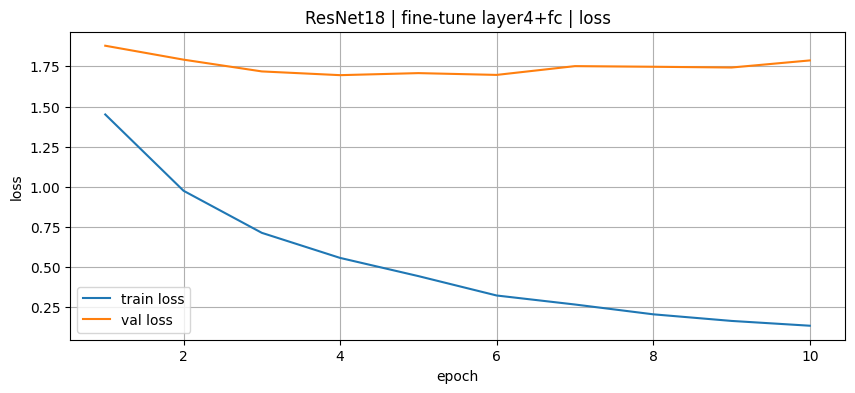

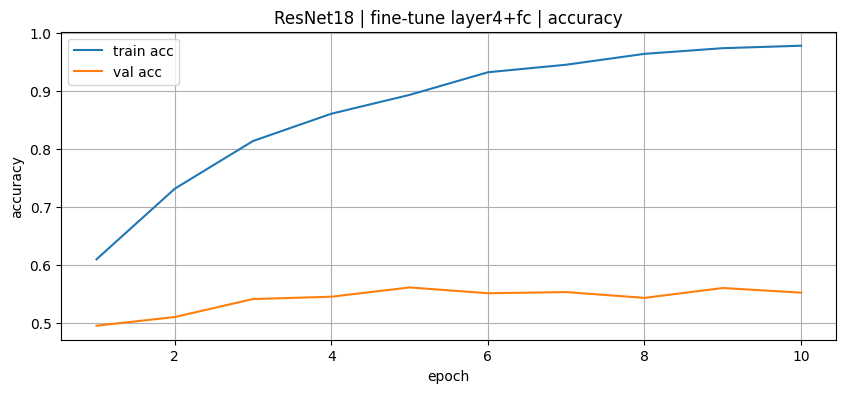

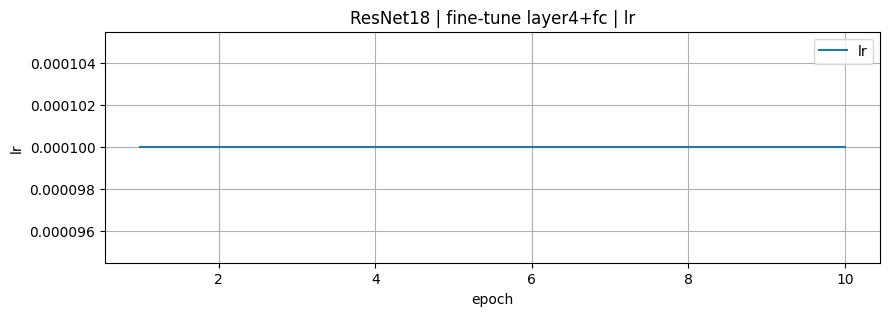

best_val_acc:  0.561


In [127]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit_ResNet18(model_head, train_loader_с3, val_loader_с3, optimizer_ft, criterion, epochs=10, verbose=True)
plot_history_ResNet18(hist_ft, title="ResNet18 | fine-tune layer4+fc")
best_val_acc_с4 = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc_с4)

test-часть для финальной оценки лучшей модели

In [128]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader_с3)
print("Test acc:", round(test_acc, 4))

Test acc: 0.58


показываем что лучший результат действительно достигается при последнем эксперементе

In [132]:
print(max(best_val_acc_с1,best_val_acc_с2,best_val_acc_с3,best_val_acc_с4)) 

0.561


сохранение графика train/val loss для лучшего прогона классификации

In [151]:
save_plot_history_ResNet18("artifacts/figures/classification_curves_best.png",hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [133]:
# сохранение лучшей модели (С4)

tmp_path = 'artifacts/best_classifier.pt'
torch.save(model_head.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')


saved to artifacts/best_classifier.pt size: 44989771 bytes


In [4]:
# функция для сохранения файлов формата json
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

конфиг лучшей модели части A 

In [5]:
# конфиг лучшей модели
best_config = {
    "architecture": {
        "name": "ResNet18",
        "input_size": [3, 224, 224],
        "backbone": {
        "type": "resnet18",
        "frozen_layers": ["conv1", "layer1", "layer2", "layer3"],
        "trainable_layers": ["layer4"]
         },
        "classifier": {
            "type": "linear",
            "input_dim": 512,
            "num_classes": 100,
            "trainable": True
        },
        "pretrained": True
    },
    'transforms': {
        'train': [
            'RandomResizedCrop(224, scale=(0.7, 1.0))',
            'RandomHorizontalFlip(p=0.5)'
        ],
        'test': [
            'CenterCrop(224)'
        ]
    },
    
    'preprocess': {
        'resize': 'Resize(256)',
        'to_tensor': 'ToTensor()',
        'normalize': {
            'mean': (0.485, 0.456, 0.406),
            'std': (0.229, 0.224, 0.225)
        }
    },
    'augmentation': {
        'random_resized_crop': {
            'size': 224,
            'scale': (0.7, 1.0)
        },
        'random_horizontal_flip': {
            'probability': 0.5
        }
    },
    "hyperparameters": {
        'learning_rate': {
            'head_only_phase': {'fc': 1e-3},
            'fine_tune_phase': {'layer4': 1e-4, 'fc': 1e-3}
        },
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        'weight_decay': 1e-4,
        'batch_size': 64,
        
    },
    "seed": 42,  
    "dataset": "CIFAR100"  
}

save_json(best_config, Path("artifacts/best_classifier_config.json"))

краткое сравнение C1-C4 через bar plot по best_val_accuracy

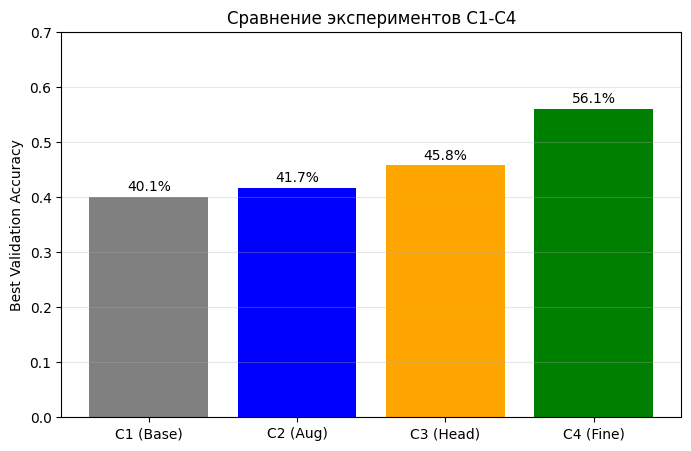

In [149]:
experiments = ['C1 (Base)', 'C2 (Aug)', 'C3 (Head)', 'C4 (Fine)']
accuracies = [best_val_acc_с1,best_val_acc_с2,best_val_acc_с3,best_val_acc_с4]

plt.figure(figsize=(8, 5))
bars = plt.bar(experiments, accuracies, color=['gray', 'blue', 'orange', 'green'])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontsize=10)

plt.ylabel('Best Validation Accuracy')
plt.title('Сравнение экспериментов C1-C4')
plt.ylim(0, 0.7)
plt.grid(axis='y', alpha=0.3)
plt.savefig("artifacts/figures/classification_compare.png", dpi=100,bbox_inches='tight')
plt.show()

создание таблицы результатов по всем экспериментам части A и части B и частичное заполнение ее

In [165]:
# Твои данные
c1_data = {
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'CIFAR-100',
    'seed': 42,
    'model_summary': 'SimpleCNN (3 conv layers, 2 fc)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': 15,
    'best_val_accuracy': best_val_acc_с1,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'Baseline without augmentation'
}

c2_data = {
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'CIFAR-100',
    'seed': 42,
    'model_summary': 'SimpleCNN (3 conv layers, 2 fc)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': 15,
    'best_val_accuracy': best_val_acc_с2,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'With augmentation (RandomCrop+HorizontalFlip)'
}

c3_data = {
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'CIFAR-100',
    'seed': 42,
    'model_summary': 'ResNet18 pretrained on ImageNet, head-only training',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': 10,
    'best_val_accuracy': best_val_acc_с3,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'Transfer learning: only fc layer trained'
}

c4_data = {
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'CIFAR-100',
    'seed': 42,
    'model_summary': 'ResNet18 pretrained on ImageNet, fine-tuned layer4+fc',
    'optimizer': 'Adam',
    'lr': '1e-4 (layer4), 1e-3 (fc)',
    'epochs_trained': 10,
    'best_val_accuracy': best_val_acc_с4,
    'test_accuracy': round(test_acc, 4),
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'Fine-tuning layer4+fc'
}

# Сохраняем все сразу (перезаписывает файл)
all_data = [c1_data, c2_data, c3_data, c4_data]
pd.DataFrame(all_data).to_csv("artifacts/runs.csv", index=False)
print("Сохранено в artifacts/runs.csv")

Сохранено в artifacts/runs.csv


изменение параметра без перезаписи других данных

In [1]:
df = pd.read_csv("artifacts/runs.csv")
mask = df['experiment_id'] == 'C4'
df.loc[mask, 'lr'] = 1e-4
# Сохраняем обратно (без перезаписи других данных)
df.to_csv("artifacts/runs.csv", index=False)
print("Значение обновлено в artifacts/runs.csv")

Значение обновлено в artifacts/runs.csv


визуализация аугментаций для части A

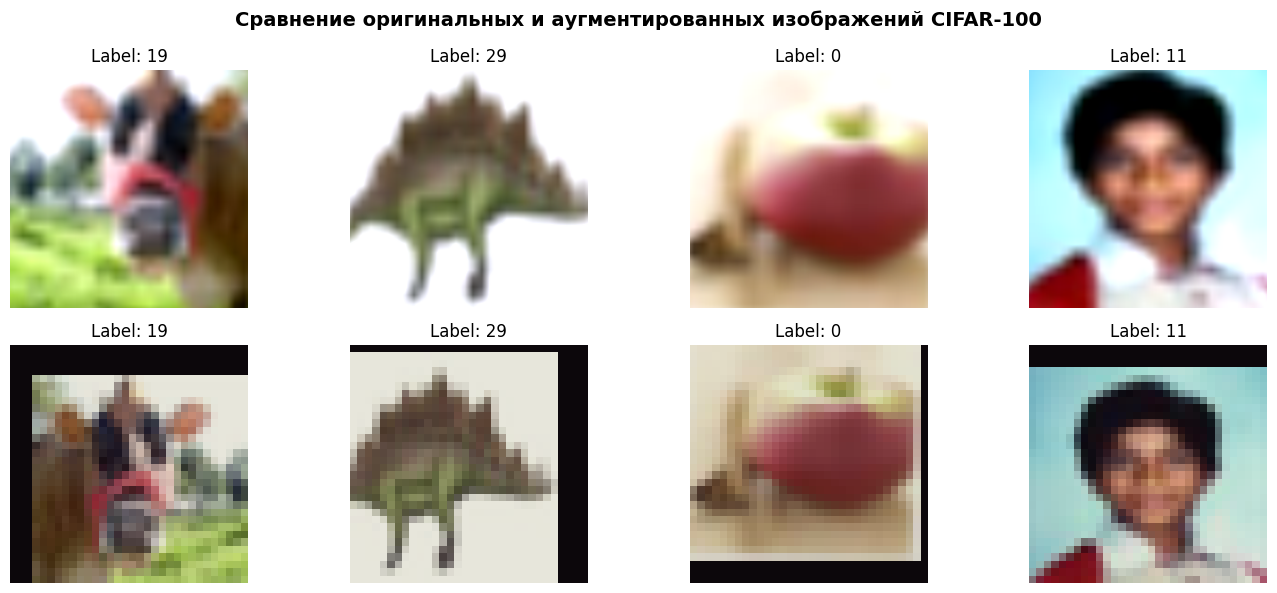

In [172]:
# Функция денормализации
def denormalize(tensor, mean, std):
    """Возвращает изображение из нормализованного в обычный вид [0,1]"""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

# Средние и std для разных датасетов
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Визуализация
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    # Без аугментации (CIFAR100_MEAN)
    img_no_aug, label_no_aug = ds_train_eval[i]
    img_no_aug = denormalize(img_no_aug, CIFAR100_MEAN, CIFAR100_STD)
    axes[0, i].imshow(img_no_aug.permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"Label: {label_no_aug}")
    axes[0, i].axis('off')
    
    # С аугментацией (IMAGENET_MEAN)
    img_aug, label_aug = ds_train_aug[i]
    img_aug = denormalize(img_aug, IMAGENET_MEAN, IMAGENET_STD)
    axes[1, i].imshow(img_aug.permute(1, 2, 0).numpy())
    axes[1, i].set_title(f"Label: {label_aug}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("БЕЗ аугментации\n(оригинал 32x32)", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("С аугментацией\n(224x224 + кроп + флип)", fontsize=12, fontweight='bold')

plt.suptitle("Сравнение оригинальных и аугментированных изображений CIFAR-100", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=100,bbox_inches='tight')
plt.show()


ЧАСТЬ В

скачивание датасета Pascal VOC через torchvision.datasets

In [9]:
dataset = VOCDetection(
    root='./data',
    year='2012',
    image_set='trainval',
    download=True  
)

100.0%


визуализация датасета

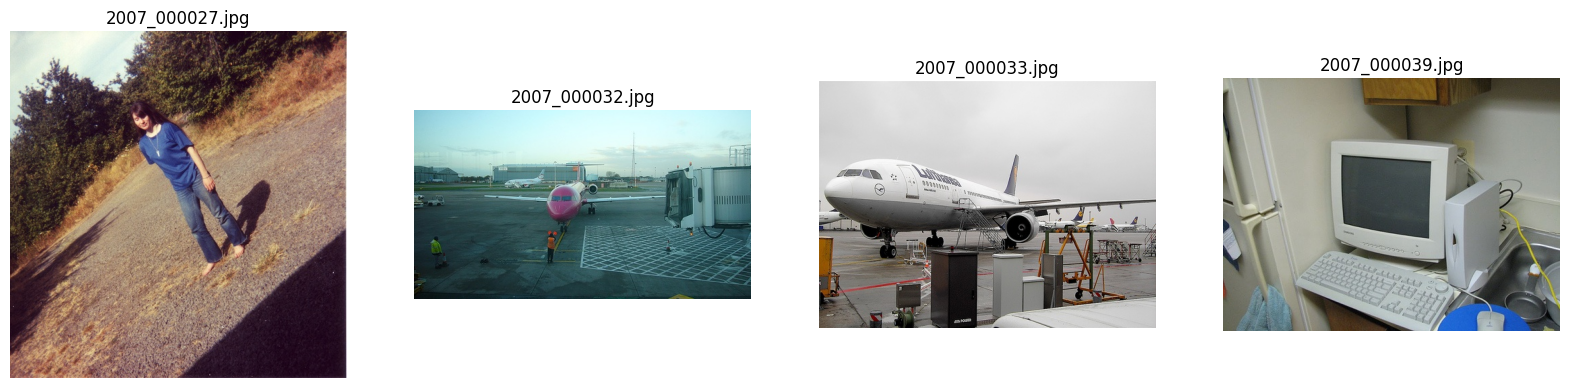

In [36]:
img_dir = "./data/VOCdevkit/VOC2012/JPEGImages"
all_imgs = sorted(os.listdir(img_dir))[:4]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img = Image.open(os.path.join(img_dir, all_imgs[i]))
    axes[i].imshow(img)
    axes[i].set_title(all_imgs[i])
    axes[i].axis('off')

plt.savefig("artifacts/figures/detection_examples.png", dpi=100,bbox_inches='tight')
plt.show()

читаем изображения и извлекаем рамки

In [29]:
class PascalVOCDetDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "JPEGImages")        
        self.xml_dir = os.path.join(root, "Annotations")       

        self.xml_files = sorted([f for f in os.listdir(self.xml_dir) if f.endswith(".xml")])
        self.imgs = [f.replace('.xml', '.jpg') for f in self.xml_files]

        if len(self.imgs) == 0:
            raise RuntimeError("Похоже, структура Pascal VOC повреждена или не распакована полностью.")

        # маппинг классов Pascal VOC в индексы COCO
        self.voc_to_coco = {
            'person': 1,
            'bicycle': 2,
            'car': 3,
            'motorbike': 4,
            'aeroplane': 5,
            'bus': 6,
            'train': 7,
            'boat': 9,
            'bird': 16,
            'cat': 17,
            'dog': 18,
            'horse': 19,
            'sheep': 20,
            'cow': 21,
            'bottle': 44,
            'chair': 62,
            'diningtable': 67,
            'pottedplant': 64,
            'sofa': 63,
            'tvmonitor': 72
        }

        try:
            from torchvision.transforms import ToTensor
            self.to_tensor = ToTensor()
        except Exception as e:
            raise RuntimeError("Нужен torchvision для ToTensor().") from e

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        xml_path = os.path.join(self.xml_dir, self.xml_files[idx])

        img = Image.open(img_path).convert("RGB")
        
        tree = ET.parse(xml_path)
        root_xml = tree.getroot()
        
        boxes = []
        labels = []
        
        for obj in root_xml.findall('object'):
            # Пропускаем сложные примеры
            difficult = obj.find('difficult')
            if difficult is not None and int(difficult.text) == 1:
                continue
            
            name = obj.find('name').text
            label = self.voc_to_coco.get(name, 0)
            
            if label == 0:  # если класс не найден
                continue
                
            labels.append(label)  # ← теперь индексы как в COCO (1-80)
            
            # Координаты bounding box
            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)
            boxes.append([xmin, ymin, xmax, ymax])

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)

        image_id = torch.tensor([idx], dtype=torch.int64)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        img_t = self.to_tensor(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

# Использование
voc_root = "./data/VOCdevkit/VOC2012"
dataset = PascalVOCDetDataset(voc_root)
print(f"Изображений: {len(dataset)}")
img, target = dataset[0]
print(f"Форма: {img.shape}")
print(f"Ключи: {target.keys()}")

Изображений: 17125
Форма: torch.Size([3, 500, 486])
Ключи: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])


In [ ]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()
train_loader, val_loader, test_loader = make_loaders(ds_train_no_aug, ds_test,128)
show_images(train_loader, n=10)

Использую готовую pretrained detection-модель FasterRCNN_ResNet50_FPN

In [30]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights
    )

    name = name.strip()

    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)

    categories = weights.meta.get("categories", None)

    model.eval()
    return model, weights, categories

model, weights, categories = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)

model: fasterrcnn_mobilenet_v3_large_fpn


In [31]:
# Инференс и визуализация bbox
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out


def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    return {k: v[keep] for k, v in pred.items()}

In [32]:
# IoU sanity-check: TP/FP/FN при IoU>=thr (это НЕ mAP, но уже честная проверка)

def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(
    pred_boxes: torch.Tensor, 
    pred_scores: torch.Tensor, 
    pred_labels: torch.Tensor,
    gt_boxes: torch.Tensor, 
    gt_labels: torch.Tensor,
    iou_thr: float
) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]
    pred_labels = pred_labels[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j] and pred_labels[p] == gt_labels[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou
   
    

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, score_thr)  

        
        tp, fp, fn, miou = match_greedy(
            pred_f["boxes"], 
            pred_f["scores"], 
            pred_f["labels"],      
            target["boxes"], 
            target["labels"],       
            iou_thr
        )
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }


V1: inference при score_threshold = 0.3

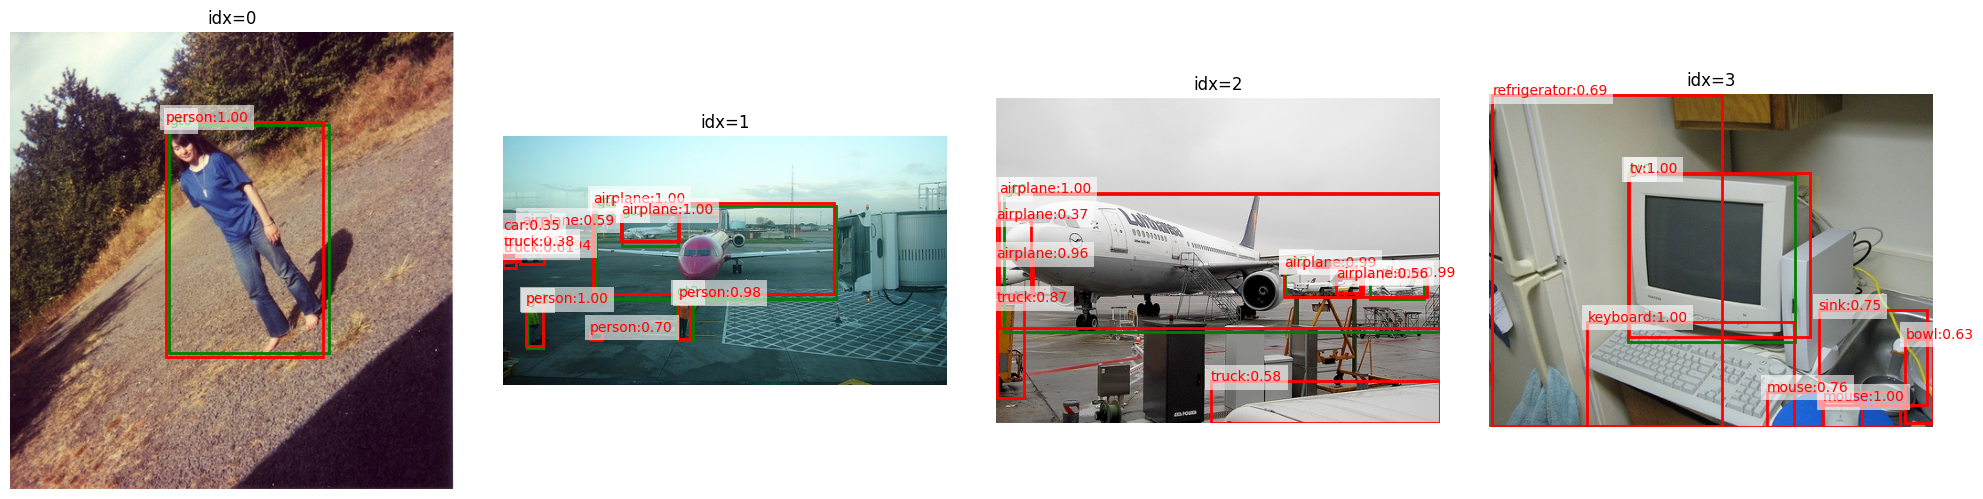

{'TP': 38.0,
 'FP': 100.0,
 'FN': 0.0,
 'precision@IoU': 0.27536231883858436,
 'recall@IoU': 0.9999999999736843,
 'F1@IoU': 0.4318181814746901,
 'mean_IoU_matched': 0.8974686957399051}

In [33]:
n_show: int = 4                 # сколько картинок показать
score_thr: float = 0.3         # порог уверенности
iou_thr: float = 0.5


# Покажем несколько примеров
n = min(n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]


coco_classes = categories  # список всех 80 классов COCO
for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, score_thr)  

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный (из датасета)
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    
    # Pred - красный (все классы!)
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, 
               text=lambda j: f"{coco_classes[pred_f['labels'][j]]}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()


eval_indices = list(range(min(20, len(dataset))))
metrics = evaluate_subset(eval_indices)
metrics

V2: inference при score_threshold = 0.7

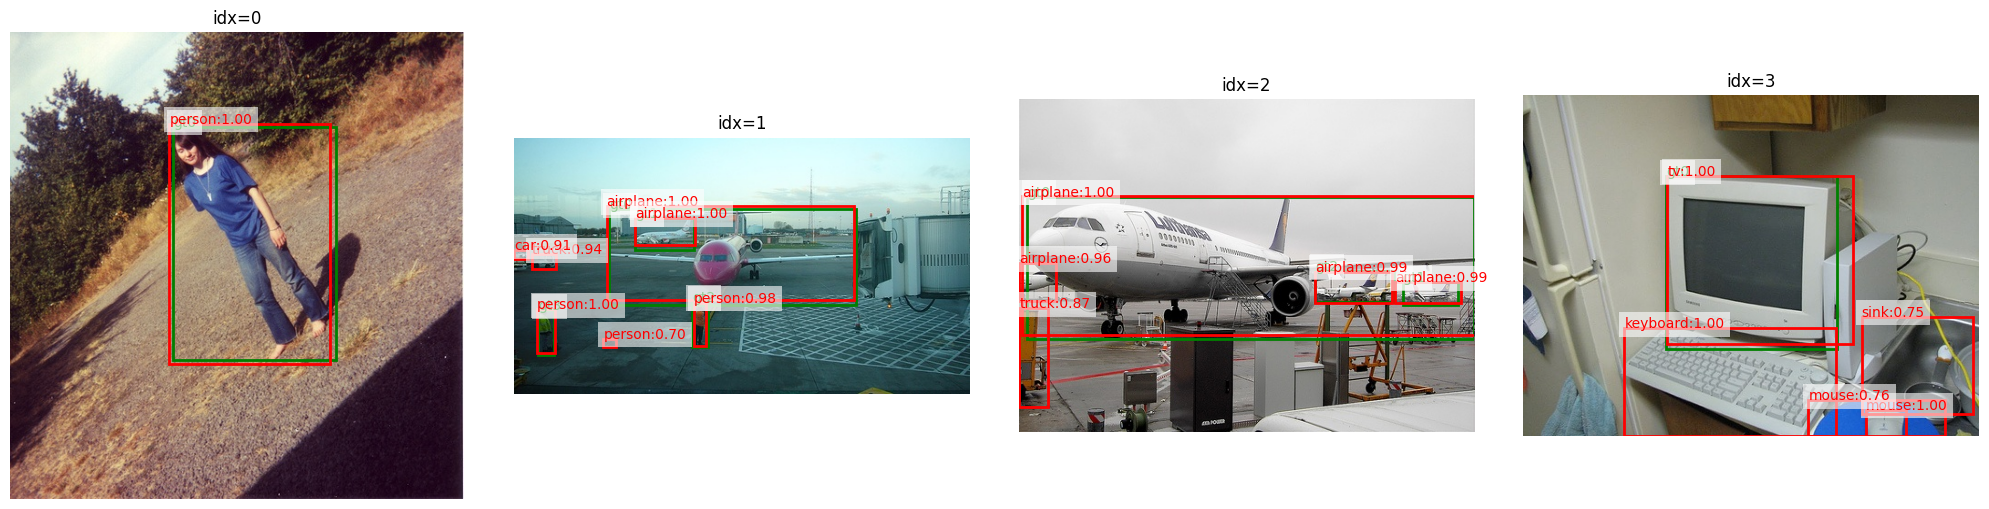

{'TP': 36.0,
 'FP': 45.0,
 'FN': 2.0,
 'precision@IoU': 0.4444444444389575,
 'recall@IoU': 0.9473684210277009,
 'F1@IoU': 0.6050420163618389,
 'mean_IoU_matched': 0.8933973884373381}

In [37]:
n_show: int = 4                 # сколько картинок показать
score_thr: float = 0.7         # порог уверенности
iou_thr: float = 0.5


# Покажем несколько примеров
n = min(n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]


coco_classes = categories  # список всех 80 классов COCO
for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, score_thr)  

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный (из датасета)
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    
    # Pred - красный (все классы!)
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, 
               text=lambda j: f"{coco_classes[pred_f['labels'][j]]}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.savefig("artifacts/figures/detection_metrics.png", dpi=100,bbox_inches='tight')
plt.show()


eval_indices = list(range(min(20, len(dataset))))
metrics = evaluate_subset(eval_indices)
metrics

добавление в таблицу результатов

In [38]:
c5_data = {
    'experiment_id': 'V1',
    'task': 'detection',
    'dataset': 'Pascal VOC',
    'seed': 42,
    'model_summary': 'FasterRCNN_ResNet50_FPN',
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_accuracy': None,  
    'test_accuracy': None,
    'precision': 0.275,
    'recall': 0.999,
    'mean_iou': 0.897,
    'notes': 'min score_thr(0.3 )'
}

# Читаем старый файл
if os.path.exists("artifacts/runs.csv"):
    df_old = pd.read_csv("artifacts/runs.csv")
    # Добавляем новый
    df_new = pd.concat([df_old, pd.DataFrame([c5_data])], ignore_index=True)
else:
    df_new = pd.DataFrame([c5_data])

# Сохраняем
df_new.to_csv("artifacts/runs.csv", index=False)
print("Добавлен V1")

Добавлен V1


C:\Users\fazil\AppData\Local\Temp\ipykernel_13704\82018876.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_old, pd.DataFrame([c5_data])], ignore_index=True)


In [39]:
c6_data = {
    'experiment_id': 'V2',
    'task': 'detection',
    'dataset': 'Pascal VOC',
    'seed': 42,
    'model_summary': 'FasterRCNN_ResNet50_FPN',
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_accuracy': None,  
    'test_accuracy': None,
    'precision': 0.444,
    'recall': 0.947,
    'mean_iou': 0.894,
    'notes': 'mean score_thr(0.7)'
}

# Читаем старый файл
if os.path.exists("artifacts/runs.csv"):
    df_old = pd.read_csv("artifacts/runs.csv")
    # Добавляем новый
    df_new = pd.concat([df_old, pd.DataFrame([c6_data])], ignore_index=True)
else:
    df_new = pd.DataFrame([c6_data])

# Сохраняем
df_new.to_csv("artifacts/runs.csv", index=False)
print("Добавлен V2")

Добавлен V2


C:\Users\fazil\AppData\Local\Temp\ipykernel_13704\623350180.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_old, pd.DataFrame([c6_data])], ignore_index=True)
